## BASIC PREPROCESSING

Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

LOAD DATASET

Data set :Amazon Fine Food Reviews



In [2]:
df = pd.read_csv(r"C:\Users\91904\Desktop\ksfe\AI\CODE\review_rating_system\data\Reviews.csv", encoding='utf-8')

In [3]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [4]:
df.shape

(568454, 10)

The given dataset contain
row = 568454
columns =10

In [5]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

SELECT COLUMNS

I kept only Text and Score because Text is the input used to predict the review rating, while Score is the target variable. The other columns were removed because they are not needed for this NLP prediction task.

In [6]:
df = df[['Score','Text']]

REMOVE EMPTY VALUES

In [7]:
df.isnull().sum()

Score    0
Text     0
dtype: int64

There are no null values

In [8]:
df = df.dropna(subset=["Text", "Score"])

REMOVE EMPTY TEXT

In [9]:

df = df[df["Text"].str.strip() != ""]


There are no missing values.

REMOVE DUPLICATE (BOTH Text and Score are the same) 

In [10]:

df = df.drop_duplicates(subset=["Text", "Score"], keep="first")

After removing duplicates: (393675, 2)

FIND CONFLICTING TEXTS (texts that have more than one different score)

In [11]:
conflicting_texts = df.groupby("Text")["Score"].nunique()
conflicting_texts = conflicting_texts[conflicting_texts > 1]

Number of conflicting texts: 191

GET ALL ROWS FOR CONFLICTING TEXTS

In [ ]:

# Get rows containing conflicting texts
conflicting_df = df[df["Text"].isin(conflicting_texts.index)]

# Count Text + Score
result = (
    conflicting_df
    .groupby(["Text", "Score"])
    .size()
    .reset_index(name="Count")
)
print(result)


In [13]:
df.shape

(393675, 2)

REMOVE ALL ROWS BELONGING TO CONFLICTING TEXT VALUES

I removed conflicting text values because the same review text had different ratings. These conflicting labels can confuse the model during training, so I removed them to maintain consistent and reliable training data.

In [14]:

df = df[~df["Text"].isin(conflicting_texts)]

After removing conflicts: (393675, 2)

SAVE NEW CSV IN THE DATA FOLDER

In [15]:
df.to_csv(
    r"C:\Users\91904\Desktop\ksfe\AI\CODE\review_rating_system\data\cleaned_reviews.csv",
    index=False
)

DATA VISUALIZATION

1. Rating Distribution

Score
1     36280
2     20804
3     29772
4     56074
5    250745
Name: count, dtype: int64


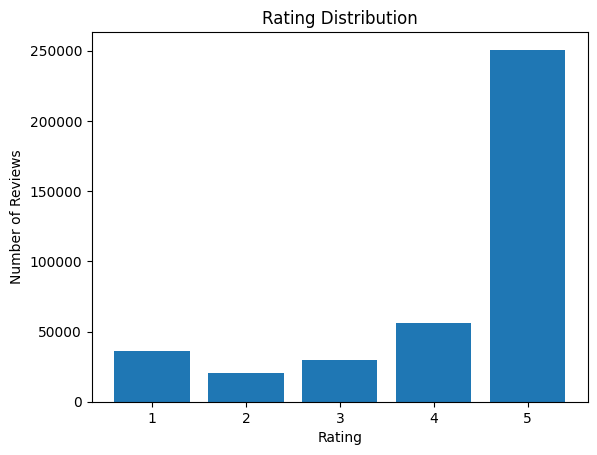

In [16]:

score_counts = df["Score"].value_counts().sort_index()
print(score_counts)

plt.bar(score_counts.index, score_counts.values)

plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Rating Distribution")

plt.show()